# Flagging Vendor Invoices for Manual Review
Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with transaction volume.

Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.

An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [ ]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your specific local path
db_path = r"C:\Users\user\Desktop\Invoice Intelligence System\data\inventory.db"

# Establishing the connection
conn = sqlite3.connect(db_path)

In [2]:
# Fetch all table names from the database and display the first 5 rows of each
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql(f"select * from {table} limit 5", conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
# Aggregate purchase data by PO Number to calculate brand variety, quantity, cost, and receiving delays
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [7]:
# Fetch specific invoice details and calculate timeline metrics
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [12]:
# Create a temporary result set (purchase_agg) and join it with vendor invoices
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

In [13]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [14]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [15]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [16]:
def create_invoice_risk_label(row):
    
    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
        
    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
        
    return 0

# Apply the function to each row of the dataframe
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)

# Check the balance of flagged vs. non-flagged invoices
df["flag_invoice"].value_counts()

0    3693
1    1850
Name: flag_invoice, dtype: int64

<Axes: >

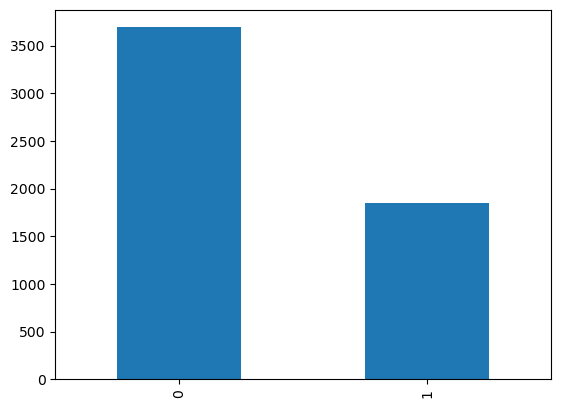

In [18]:
# Visualize the distribution of flagged vs. non-flagged invoices
df['flag_invoice'].value_counts().plot(kind = 'bar')

In [20]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


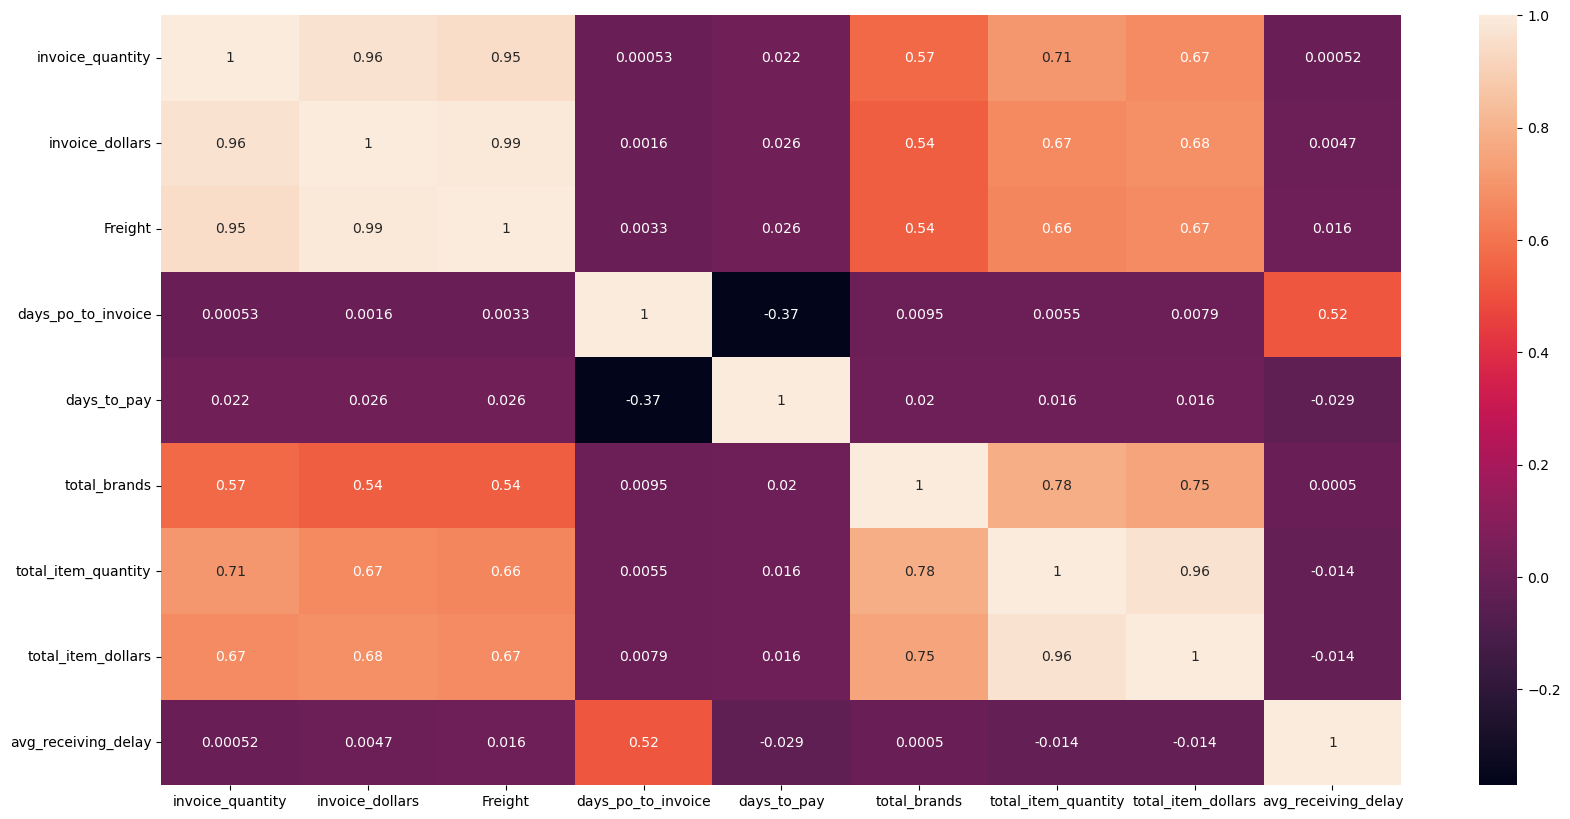

In [21]:
# Refine the correlation heatmap by slicing specific columns using iloc
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:, 1:-1].corr(), annot=True)
plt.show()

In [22]:
# Separate the dataset into flagged (high risk) and normal (low risk) groups
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [23]:
# Initialize containers for statistical analysis results
significant_features = []
non_significant_features = []
results = []

In [24]:
# Define the list of numerical columns to be tested
metrics = [
    'invoice_quantity', 'invoice_dollars', 'Freight',
    'days_po_to_invoice', 'days_to_pay', 'total_brands',
    'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay'
]

In [25]:
from scipy.stats import ttest_ind
# Iterate through each metric to perform statistical t-tests
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    
    # Perform Welch's t-test (equal_var=False) to handle different sample sizes/variances
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    
    # Check for statistical significance (Alpha = 0.05)
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

In [26]:
# Display list of features that did not show a statistical difference
non_significant_features

['days_to_pay', 'total_brands']

In [27]:
# Display list of features that are statistically linked to invoice risk
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [28]:
# View the detailed mean comparisons and p-values for significant features
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [50]:
# Select the significant features as the input for the model
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice', 'total_item_dollars']]

# Define the target variable the model will predict
y = df['flag_invoice']

In [31]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [51]:
# Data Splitting: Partition the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
# Feature Scaling: Normalize training and testing data to a standard scale
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# Model Imports: Load various classification algorithms for training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [54]:
# Model 1: Initialize and train a Logistic Regression classifier
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

# Model 2: Initialize and train a Decision Tree classifier
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

# Model 3: Initialize and train a Random Forest classifier
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [55]:
# Model Evaluation Function: Define how to calculate and print model performance
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, predictions))
    print("\n")

# Now you can run the evaluation block from your photo
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

--- Logistic Regression ---
Accuracy: 0.66
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109



--- Decision Tree Classifier ---
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109



--- Random Forest Classifier ---
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      0.68      0.79       384

    accuracy                           

In [56]:
# Feature Importance: Extract and sort the importance of each feature
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

# Display the resulting table
feature_importance

,feature,importance
6,total_item_dollars,0.219493
4,total_item_quantity,0.176710
0,invoice_quantity,0.151379
1,invoice_dollars,0.151227
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [57]:
# Data Selection: Define features (X) and the target variable (y)
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

# Data Splitting: Partition the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling: Standardize the features to ensure they are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training: Initialize and train the Random Forest Classifier
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

# Model Evaluation: Check the performance of the trained model using the test set
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

--- Random Forest Classifier ---
Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109





In [59]:
# Hyperparameter Grid: Define the range of values to test for model optimization
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

In [60]:
# Imports: Tools for custom scoring and automated parameter searching
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

# Model Setup: Initialize Random Forest to use all available CPU cores (n_jobs=-1)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Parameter Grid: Dictionary of different settings to test
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

# Grid Search Setup: Configure the search using F1-score and 5-fold cross-validation
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Execution: Run the search and evaluate the resulting best model
grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
--- Random Forest Classifier ---
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109





In [61]:
# Metrics: Import confusion matrix to see detailed correct/incorrect prediction counts
from sklearn.metrics import confusion_matrix

In [62]:
# Evaluation: Generate the confusion matrix for the optimized grid_search model
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 110],
       [ 12, 274]], dtype=int64)

In [63]:
# Evaluation: Generate the confusion matrix for the initial model3 for comparison
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]], dtype=int64)

In [64]:
# Results: Display the specific hyperparameters that yielded the best performance
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}